# 📊 CodeAlpha Data Science Internship - Task 2
# 🔍 Unemployment Analysis with Python

**Internship Organization:** CodeAlpha  
**Track:** Data Science  
**Task:** Task 2 — Unemployment Analysis with Python  
**Author:** Data Science Intern  
**Repository Name:** `CodeAlpha_UnemploymentAnalysis`

---

## 🎯 1. Project Objective

The primary objective of this project is to perform a comprehensive, data-driven analysis of the **Unemployment Rate in India**.

Key goals include:
1. **Data Cleaning & Exploration:** Inspect raw records, resolve null values, correct data types, and prepare time-series fields.
2. **Trend Analysis:** Track changes in national unemployment rates over time (May 2019 to June 2020).
3. **COVID-19 Impact Investigation:** Measure the quantitative impact of the COVID-19 pandemic and national lockdown on employment, labor participation, and state-level job markets.
4. **Demographic & Geographic Disparities:** Compare unemployment patterns across Indian States and Union Territories, as well as between **Rural** and **Urban** regions.
5. **Actionable Insights & Policy Implications:** Derive key findings that can inform social safety nets, workforce resilience policies, and economic recovery programs.

## 📖 2. Introduction & Domain Concepts

### What is the Unemployment Rate?
The **Unemployment Rate** is defined as the percentage of the active labor force that is jobless, available for work, and actively seeking employment.
$$\text{Unemployment Rate (\%)} = \left( \frac{\text{Unemployed Individuals}}{\text{Total Active Labour Force}} \right) \times 100$$

### Key Economic Indicators in this Dataset:
- **Estimated Unemployment Rate (%)**: The proportion of the labor force without work.
- **Estimated Employed**: The absolute count of actively employed citizens in a given state/region.
- **Estimated Labour Participation Rate (%)**: The percentage of the working-age population (aged 15+) that is either employed or actively seeking work.
- **Area (Rural vs. Urban)**: Geographic classification of households to identify agrarian vs. industrial/service economic trends.

## 📦 3. Import Required Libraries

We use the core Python data science stack:
- **Pandas**: For tabular data manipulation, aggregation, and time-series handling.
- **NumPy**: For numerical computing and array operations.
- **Matplotlib & Seaborn**: For high-quality, publication-ready data visualizations.

In [ ]:
# Import essential data science libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

# Suppress minor warnings for clean notebook presentation
warnings.filterwarnings('ignore')

# Configure plot styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("Libraries imported successfully!")

Libraries imported successfully!


## 📥 4. Load Dataset

We load the official **Unemployment in India** dataset containing monthly employment statistics across Indian states and union territories.

In [ ]:
# Define dataset path and load into a pandas DataFrame
dataset_path = 'data/Unemployment in India.csv'

# If running directly in the project directory
if not os.path.exists(dataset_path):
    dataset_path = 'Unemployment in India.csv'

df = pd.read_csv(dataset_path)
print(f"Dataset successfully loaded! Total rows: {df.shape[0]}, Total columns: {df.shape[1]}")

Dataset successfully loaded! Total rows: 768, Total columns: 7


## 🔍 5. Dataset Overview & Initial Inspection

Let us inspect the first and last rows, column data types, and check for missing values or trailing empty rows.

In [ ]:
# Display first 5 rows
print("--- First 5 Rows of Raw Dataset ---")
display(df.head())

# Display last 5 rows
print("\n--- Last 5 Rows of Raw Dataset ---")
display(df.tail())

# Dataset Information (data types and non-null counts)
print("\n--- Dataset Info ---")
df.info()

# Check for missing/null values
print("\n--- Missing Values Count Per Column ---")
print(df.isnull().sum())

--- First 5 Rows of Raw Dataset ---
           Region         Date  Frequency   Estimated Unemployment Rate (%)   Estimated Employed   Estimated Labour Participation Rate (%)   Area
0  Andhra Pradesh   31-05-2019    Monthly                              3.65             11999139                                     43.24  Rural
1  Andhra Pradesh   30-06-2019    Monthly                              3.05             11755881                                     42.05  Rural
2  Andhra Pradesh   31-07-2019    Monthly                              3.75             12086707                                     43.50  Rural
3  Andhra Pradesh   31-08-2019    Monthly                              3.32             12285693                                     43.97  Rural
4  Andhra Pradesh   30-09-2019    Monthly                              5.17             12256752                                     44.68  Rural

--- Last 5 Rows of Raw Dataset ---
    Region  Date  Frequency   Estimated Unemployment

## 🧹 6. Data Cleaning & Transformation

### Observations from Initial Inspection:
1. **Trailing Null Rows**: Exactly 28 rows at the end of the file contain all `NaN` values. These are dropped.
2. **Column Names Spacing**: Column names have leading whitespace (e.g. `' Date'`, `' Estimated Unemployment Rate (%)'`). We strip all column names.
3. **String Fields Spacing**: Categorical columns (`Region`, `Area`, `Frequency`) contain whitespace padding.
4. **Date Format**: The `Date` column is stored as string objects. We convert it to standard `datetime64[ns]` format.
5. **Feature Engineering**: We extract `Year`, `Month_Num`, `Month`, `Month_Year`, and create a `COVID_Period` label (`Pre-COVID` vs `During-COVID`).

In [ ]:
# 1. Drop completely empty trailing rows
df_clean = df.dropna().copy()

# 2. Strip leading/trailing whitespaces from column names
df_clean.columns = df_clean.columns.str.strip()

# 3. Strip whitespace from string columns
for col in ['Region', 'Frequency', 'Area']:
    df_clean[col] = df_clean[col].astype(str).str.strip()

# 4. Convert Date to datetime format
df_clean['Date'] = pd.to_datetime(df_clean['Date'].str.strip(), format='%d-%m-%Y')

# 5. Extract time-based features
df_clean['Year'] = df_clean['Date'].dt.year
df_clean['Month_Num'] = df_clean['Date'].dt.month
df_clean['Month'] = df_clean['Date'].dt.strftime('%b')
df_clean['Month_Year'] = df_clean['Date'].dt.strftime('%b-%Y')

# 6. Categorize COVID-19 Period (Lockdown began late March 2020)
df_clean['COVID_Period'] = df_clean['Date'].apply(
    lambda d: 'Pre-COVID (May 2019 - Feb 2020)' if d < pd.Timestamp('2020-03-01') 
              else 'During-COVID (Mar 2020 - Jun 2020)'
)

# 7. Check for duplicate entries
duplicates = df_clean.duplicated().sum()
print(f"Cleaned Dataset Shape: {df_clean.shape[0]} rows, {df_clean.shape[1]} columns")
print(f"Duplicate records: {duplicates}")
print(f"Date Range: {df_clean['Date'].min().strftime('%d %b %Y')} to {df_clean['Date'].max().strftime('%d %b %Y')}")
print(f"Unique States/Regions: {df_clean['Region'].nunique()}")
print(f"Geographic Areas: {df_clean['Area'].unique().tolist()}")

Cleaned Dataset Shape: 740 rows, 12 columns
Duplicate records: 0
Date Range: 31 May 2019 to 30 Jun 2020
Unique States/Regions: 28
Geographic Areas: ['Rural', 'Urban']


In [ ]:
# Statistical Summary of the Cleaned Data
print("--- Statistical Summary of Key Numeric Features ---")
display(df_clean[['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']].describe().round(2))

--- Statistical Summary of Key Numeric Features ---
       Estimated Unemployment Rate (%)  Estimated Employed  Estimated Labour Participation Rate (%)
count                           740.00              740.00                                   740.00
mean                             11.79          7204460.03                                    42.63
std                              10.72          9087840.40                                     8.11
min                               0.00             49420.00                                    13.33
25%                               4.66          1190404.50                                    38.06
50%                               8.35          4744178.50                                    41.16
75%                              15.89         11275489.50                                    45.50
max                              76.74         45777509.00                                    72.57


## 📊 7. Exploratory Data Analysis (EDA)

We explore overall labor metrics across Indian states, identify regional variations, and compare rural vs. urban performance.

In [ ]:
# State-Wise Unemployment Aggregations
state_summary = df_clean.groupby('Region')['Estimated Unemployment Rate (%)'].agg(
    Mean_Unemployment='mean',
    Median_Unemployment='median',
    Min_Unemployment='min',
    Max_Unemployment='max',
    Std_Dev='std'
).sort_values(by='Mean_Unemployment', ascending=False)

print("--- Top 5 States with Highest Average Unemployment Rate ---")
display(state_summary.head(5).round(2))

print("\n--- Top 5 States with Lowest Average Unemployment Rate ---")
display(state_summary.tail(5).round(2))

--- Top 5 States with Highest Average Unemployment Rate ---
                  Mean_Unemployment  Median_Unemployment  Min_Unemployment  Max_Unemployment  Std_Dev
Region                                                                                               
Tripura                       28.35                27.31             14.71             43.64     6.06
Haryana                       26.28                25.06             14.54             46.89     7.80
Jharkhand                     20.58                17.28              5.01             70.17    16.67
Bihar                         18.92                15.01              8.87             58.77    12.63
Himachal Pradesh              18.54                18.35              1.12             50.00     9.61

--- Top 5 States with Lowest Average Unemployment Rate ---
             Mean_Unemployment  Median_Unemployment  Min_Unemployment  Max_Unemployment  Std_Dev
Region                                                               

In [ ]:
# Rural vs Urban Comparison
area_comparison = df_clean.groupby('Area').agg(
    Mean_Unemployment_Rate=('Estimated Unemployment Rate (%)', 'mean'),
    Mean_Employed_Count=('Estimated Employed', 'mean'),
    Mean_Labour_Participation=('Estimated Labour Participation Rate (%)', 'mean')
).round(2)

print("--- Rural vs Urban Labor Market Comparison ---")
display(area_comparison)

--- Rural vs Urban Labor Market Comparison ---
       Mean_Unemployment_Rate  Mean_Employed_Count  Mean_Labour_Participation
Area                                                                          
Rural                   10.32          10192852.12                       44.46
Urban                   13.17           4388626.27                       40.90


## 📈 8. Unemployment Trend Analysis Over Time

Let us track the national monthly average unemployment rate from May 2019 to June 2020.

In [ ]:
# Monthly Average Aggregations
monthly_trend = df_clean.groupby('Date').agg(
    Avg_Unemployment=('Estimated Unemployment Rate (%)', 'mean'),
    Avg_Employed=('Estimated Employed', 'mean'),
    Avg_Labour_Part=('Estimated Labour Participation Rate (%)', 'mean')
).reset_index()

print("--- Monthly National Labor Market Indicators ---")
display(monthly_trend.round(2))

--- Monthly National Labor Market Indicators ---
         Date  Avg_Unemployment  Avg_Employed  Avg_Labour_Part
0  2019-05-31              8.87    7479833.67            43.90
1  2019-06-30              9.30    7357778.69            43.75
2  2019-07-31              9.03    7404409.67            43.71
3  2019-08-31              9.64    7439504.60            43.65
4  2019-09-30              9.05    7407008.81            44.30
5  2019-10-31              9.90    7298382.49            44.00
6  2019-11-30              9.87    7282695.16            44.11
7  2019-12-31              9.50    7371195.34            43.67
8  2020-01-31              9.95    7677344.25            44.05
9  2020-02-29              9.96    7603995.83            43.72
10 2020-03-31             10.70    7224887.87            43.08
11 2020-04-30             23.64    5629402.61            35.14
12 2020-05-31             24.88    5863715.71            38.50
13 2020-06-30             11.90    7359383.18            40.55


## 🦠 9. COVID-19 Impact Analysis

The COVID-19 nationwide lockdown was implemented in late March 2020. Here we rigorously quantify the difference between:
1. **Pre-COVID Baseline**: May 2019 – February 2020 (10 months)
2. **COVID-19 Lockdown Period**: March 2020 – June 2020 (4 months)

In [ ]:
# Split data into Pre-COVID and During-COVID subsets
pre_covid_df = df_clean[df_clean['Date'] < '2020-03-01']
during_covid_df = df_clean[df_clean['Date'] >= '2020-03-01']

pre_mean = pre_covid_df['Estimated Unemployment Rate (%)'].mean()
during_mean = during_covid_df['Estimated Unemployment Rate (%)'].mean()
abs_diff = during_mean - pre_mean
pct_diff = (abs_diff / pre_mean) * 100

pre_emp = pre_covid_df['Estimated Employed'].mean()
during_emp = during_covid_df['Estimated Employed'].mean()
emp_diff = during_emp - pre_emp
emp_pct = (emp_diff / pre_emp) * 100

pre_lpr = pre_covid_df['Estimated Labour Participation Rate (%)'].mean()
during_lpr = during_covid_df['Estimated Labour Participation Rate (%)'].mean()

print("=" * 60)
print("COVID-19 IMPACT STATISTICAL SUMMARY")
print("=" * 60)
print(f"Pre-COVID Average Unemployment Rate (May 2019 - Feb 2020) : {pre_mean:.2f}%")
print(f"During-COVID Average Unemployment Rate (Mar 2020 - Jun 2020): {during_mean:.2f}%")
print(f"Absolute Increase in Unemployment Rate                    : +{abs_diff:.2f}% percentage points")
print(f"Relative Surge in Unemployment Rate                       : +{pct_diff:.2f}%")
print("-" * 60)
print(f"Pre-COVID Average Employed Count                          : {pre_emp:,.0f}")
print(f"During-COVID Average Employed Count                       : {during_emp:,.0f}")
print(f"Net Average Employment Loss                               : {emp_diff:,.0f} ({emp_pct:.2f}%)")
print("-" * 60)
print(f"Pre-COVID Labour Participation Rate                       : {pre_lpr:.2f}%")
print(f"During-COVID Labour Participation Rate                    : {during_lpr:.2f}%")
print("=" * 60)

COVID-19 IMPACT STATISTICAL SUMMARY
Pre-COVID Average Unemployment Rate (May 2019 - Feb 2020) : 9.51%
During-COVID Average Unemployment Rate (Mar 2020 - Jun 2020): 17.77%
Absolute Increase in Unemployment Rate                    : +8.26% percentage points
Relative Surge in Unemployment Rate                       : +86.91%
------------------------------------------------------------
Pre-COVID Average Employed Count                          : 7,466,028
During-COVID Average Employed Count                       : 6,517,203
Net Average Employment Loss                               : -948,825 (-12.71%)
------------------------------------------------------------
Pre-COVID Labour Participation Rate                       : 43.89%
During-COVID Labour Participation Rate                    : 39.33%


In [ ]:
# State-by-State Pre vs During COVID Impact
state_covid = df_clean.groupby(['Region', 'COVID_Period'])['Estimated Unemployment Rate (%)'].mean().unstack()
state_covid['Rate_Increase'] = state_covid['During-COVID (Mar 2020 - Jun 2020)'] - state_covid['Pre-COVID (May 2019 - Feb 2020)']
state_covid['Percentage_Increase'] = (state_covid['Rate_Increase'] / state_covid['Pre-COVID (May 2019 - Feb 2020)']) * 100

print("--- Top 5 States Most Severely Impacted by COVID-19 (Largest Rate Increase) ---")
display(state_covid.sort_values(by='Rate_Increase', ascending=False).head(5).round(2))

--- Top 5 States Most Severely Impacted by COVID-19 (Largest Rate Increase) ---
COVID_Period      During-COVID (Mar 2020 - Jun 2020)  Pre-COVID (May 2019 - Feb 2020)  Rate_Increase  Percentage_Increase
Region                                                                                                                    
Puducherry                                     38.96                             1.60          37.36              2334.34
Tamil Nadu                                     25.40                             2.83          22.57               798.81
Jharkhand                                      36.35                            14.28          22.07               154.51
Bihar                                          31.63                            13.83          17.80               128.69
Karnataka                                      15.28                             3.23          12.05               373.19


## 🗓️ 10. Pattern and Seasonal Analysis

We investigate monthly patterns, agrarian cycles vs urban manufacturing cycles, and lockdown anomalies.

In [ ]:
# Monthly patterns across 2019 vs 2020
monthly_pivot = df_clean.pivot_table(index='Month_Num', columns='Year', values='Estimated Unemployment Rate (%)', aggfunc='mean')
monthly_pivot.index = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

print("--- Year-Over-Year Monthly Comparison of Average Unemployment Rate (%) ---")
display(monthly_pivot.round(2))

--- Year-Over-Year Monthly Comparison of Average Unemployment Rate (%) ---
Year        2019   2020
Jan          NaN   9.95
Feb          NaN   9.96
Mar          NaN  10.70
Apr          NaN  23.64
May         8.87  24.88
Jun         9.30  11.90
Jul         9.03    NaN
Aug         9.64    NaN
Sep         9.05    NaN
Oct         9.90    NaN
Nov         9.87    NaN
Dec         9.50    NaN


## 🎨 11. Visualizations

Here we present five clear, publication-quality visualizations that convey the key findings.

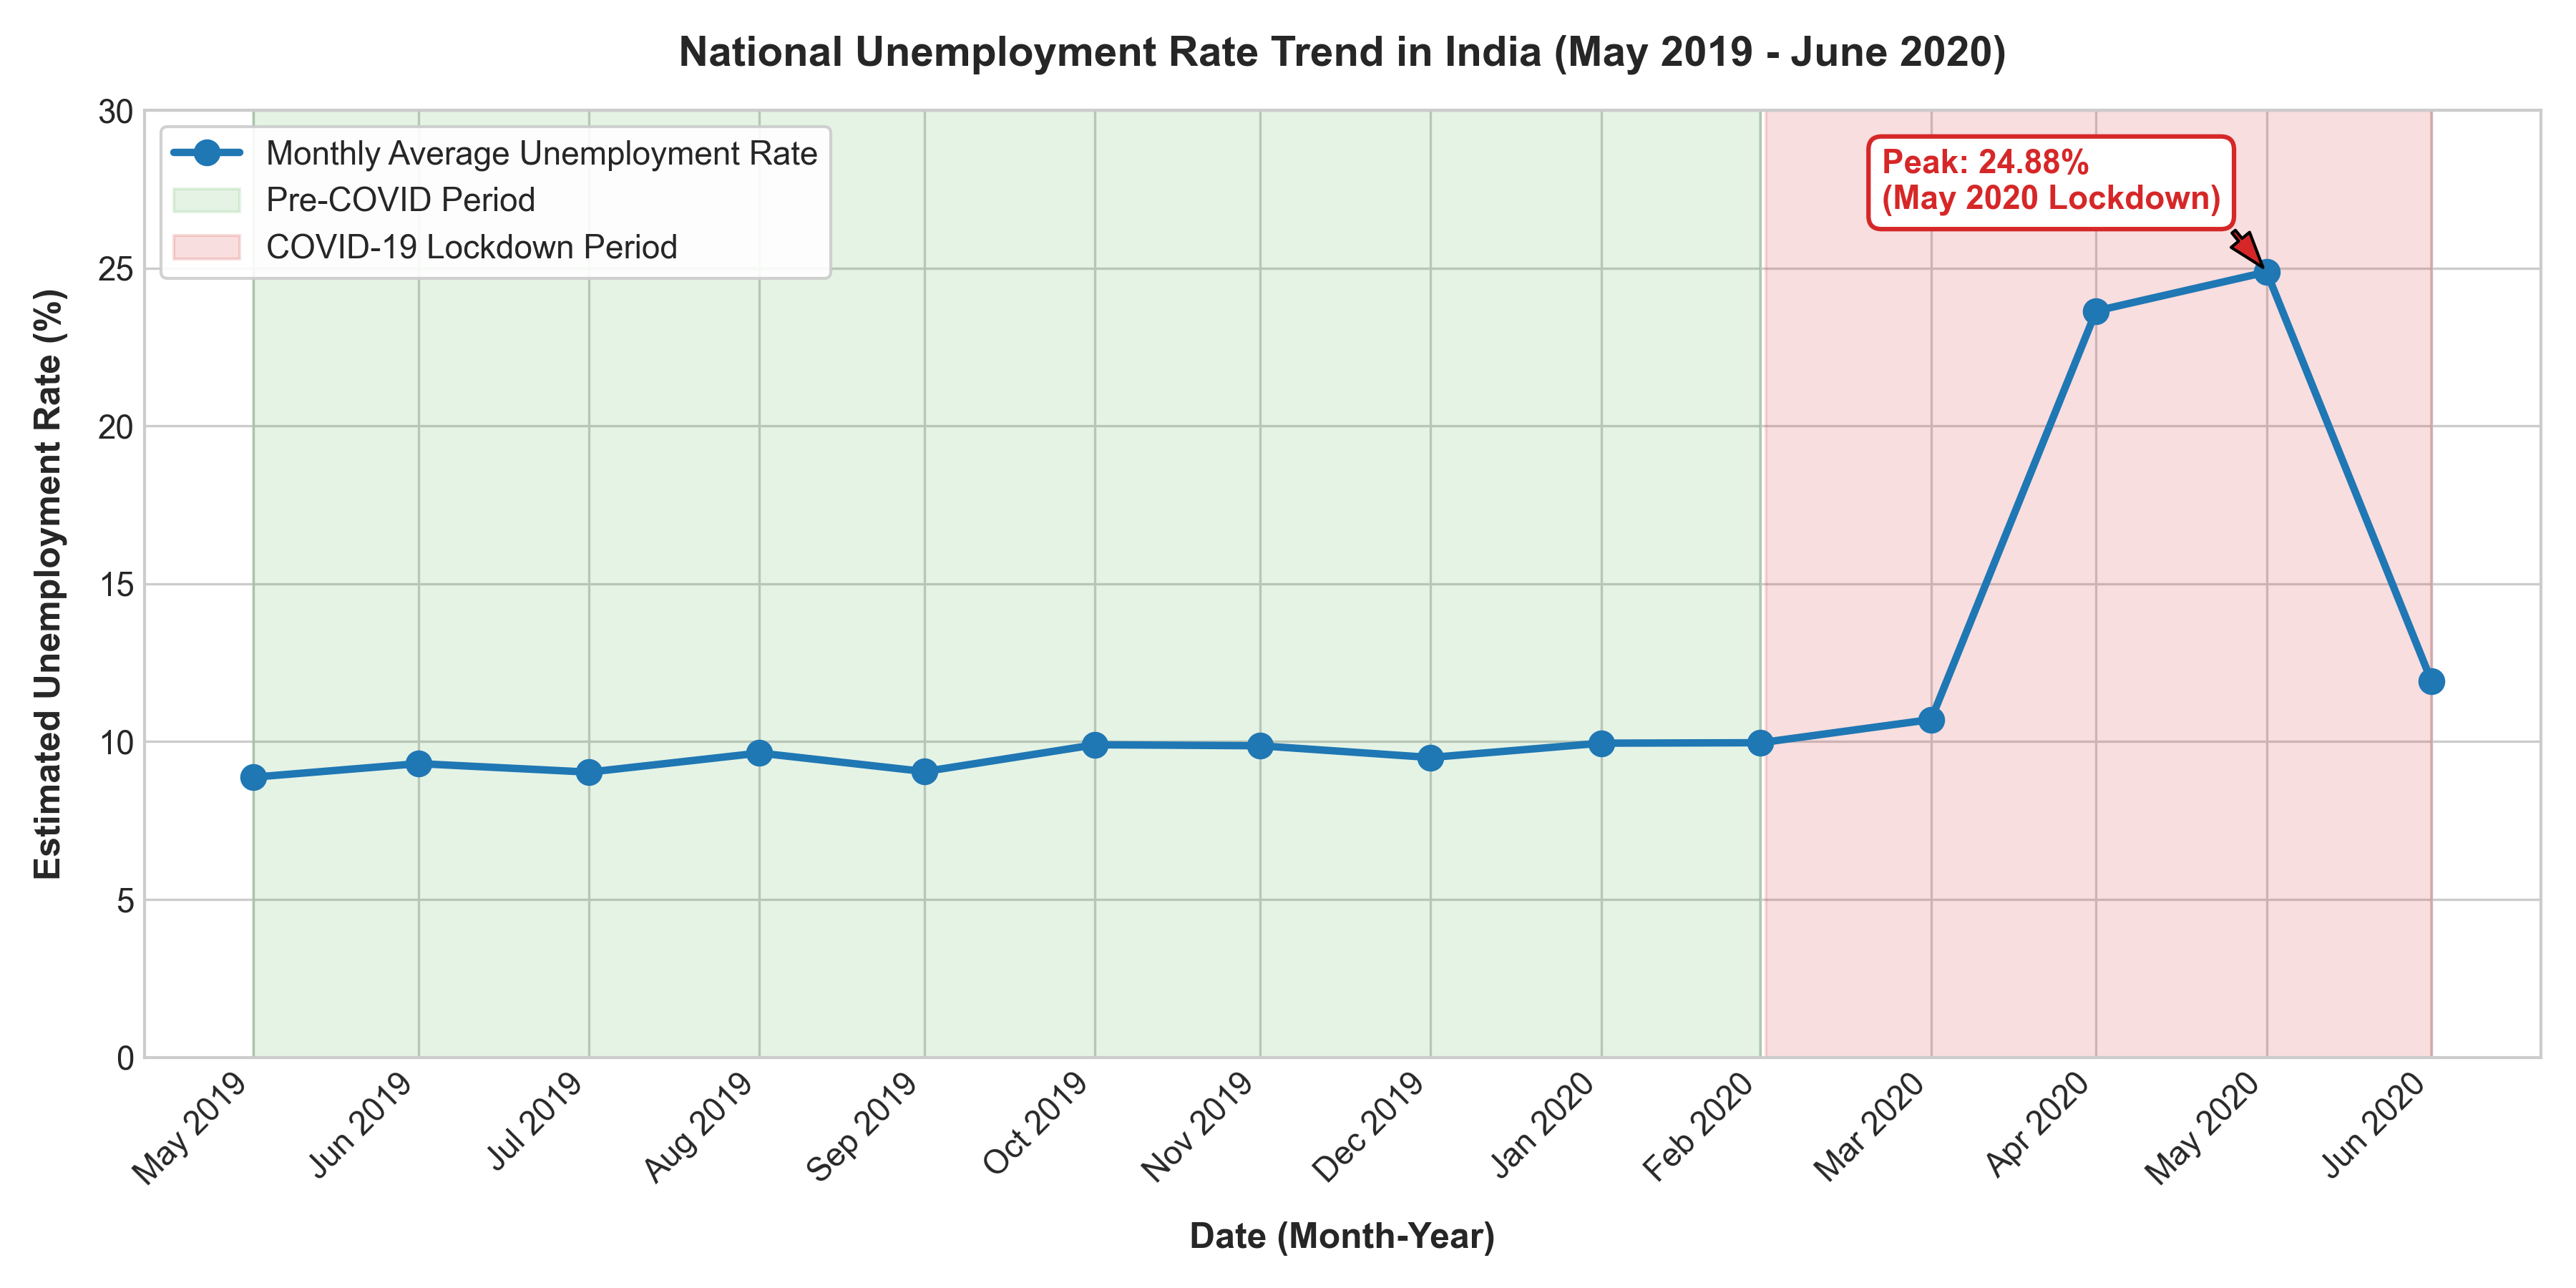

In [ ]:
# Visualization 1: National Unemployment Rate Trend Over Time
plt.figure(figsize=(12, 6))
monthly_trend_plot = df_clean.groupby('Date')['Estimated Unemployment Rate (%)'].mean().reset_index()

plt.plot(monthly_trend_plot['Date'], monthly_trend_plot['Estimated Unemployment Rate (%)'], 
         marker='o', color='#1f77b4', linewidth=2.5, markersize=8, label='Monthly National Average')

# Shade pre-COVID and COVID periods
plt.axvspan(pd.Timestamp('2019-05-31'), pd.Timestamp('2020-02-29'), color='#2ca02c', alpha=0.12, label='Pre-COVID Period')
plt.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-06-30'), color='#d62728', alpha=0.15, label='COVID-19 Lockdown Period')

# Peak annotation
peak_date = monthly_trend_plot.loc[monthly_trend_plot['Estimated Unemployment Rate (%)'].idxmax(), 'Date']
peak_val = monthly_trend_plot['Estimated Unemployment Rate (%)'].max()
plt.annotate(f'Peak: {peak_val:.2f}%\n(May 2020 Lockdown)', 
             xy=(peak_date, peak_val), 
             xytext=(peak_date - pd.Timedelta(days=75), peak_val + 2.5),
             arrowprops=dict(facecolor='#d62728', shrink=0.08, width=1.5, headwidth=8),
             fontsize=11, fontweight='bold', color='#d62728',
             bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#d62728", lw=1.5))

plt.title('Figure 1: National Unemployment Rate Trend in India (May 2019 - June 2020)', pad=15)
plt.xlabel('Date (Month-Year)', labelpad=10)
plt.ylabel('Estimated Unemployment Rate (%)', labelpad=10)
plt.ylim(0, 30)
plt.xticks(monthly_trend_plot['Date'], monthly_trend_plot['Date'].dt.strftime('%b %Y'), rotation=45, ha='right')
plt.legend(loc='upper left', frameon=True, facecolor='white')
plt.tight_layout()
plt.show()

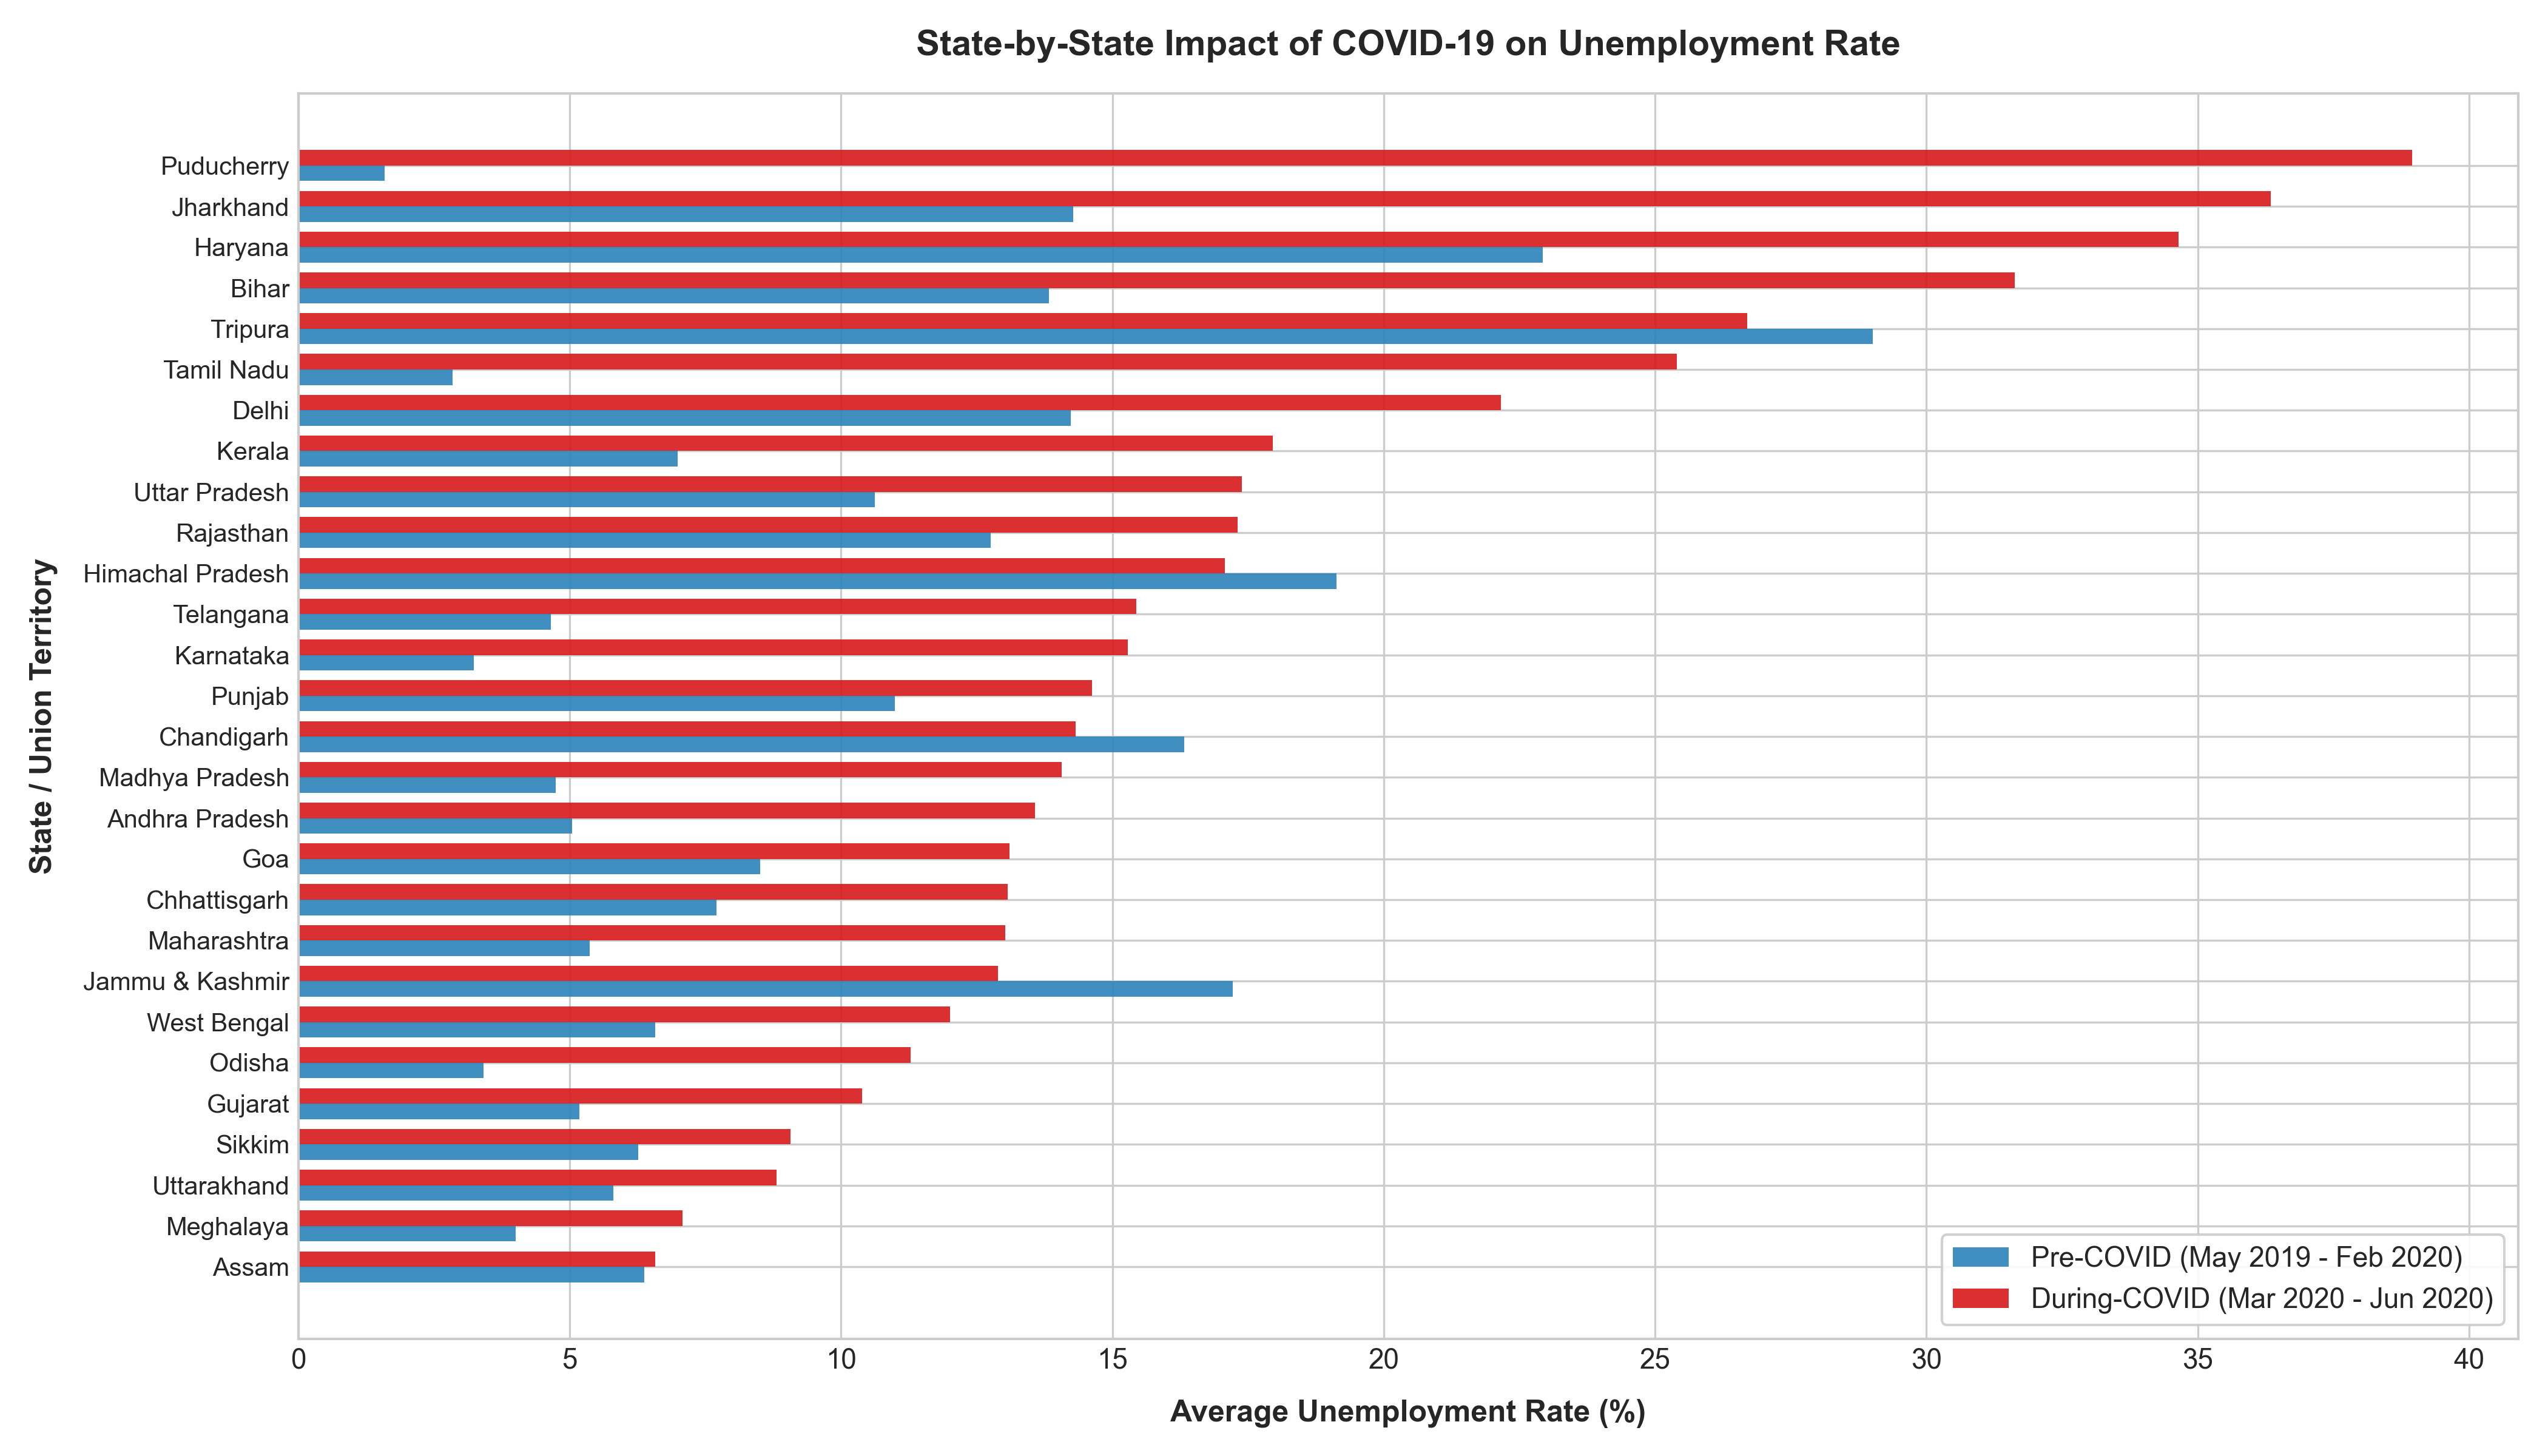

In [ ]:
# Visualization 2: COVID-19 Impact Across All Indian States
plt.figure(figsize=(14, 8))
state_covid_sorted = state_covid.sort_values(by='During-COVID (Mar 2020 - Jun 2020)', ascending=True)

y = np.arange(len(state_covid_sorted))
height = 0.38

plt.barh(y - height/2, state_covid_sorted['Pre-COVID (May 2019 - Feb 2020)'], height=height, 
         label='Pre-COVID (May 2019 - Feb 2020)', color='#2b83ba', alpha=0.9)
plt.barh(y + height/2, state_covid_sorted['During-COVID (Mar 2020 - Jun 2020)'], height=height, 
         label='During-COVID (Mar 2020 - Jun 2020)', color='#d7191c', alpha=0.9)

plt.yticks(y, state_covid_sorted.index, fontsize=10)
plt.xlabel('Average Unemployment Rate (%)', labelpad=10)
plt.ylabel('State / Union Territory', labelpad=10)
plt.title('Figure 2: State-by-State Comparison of Unemployment Rate Before vs. During COVID-19', pad=15)
plt.legend(loc='lower right', frameon=True, facecolor='white')
plt.tight_layout()
plt.show()

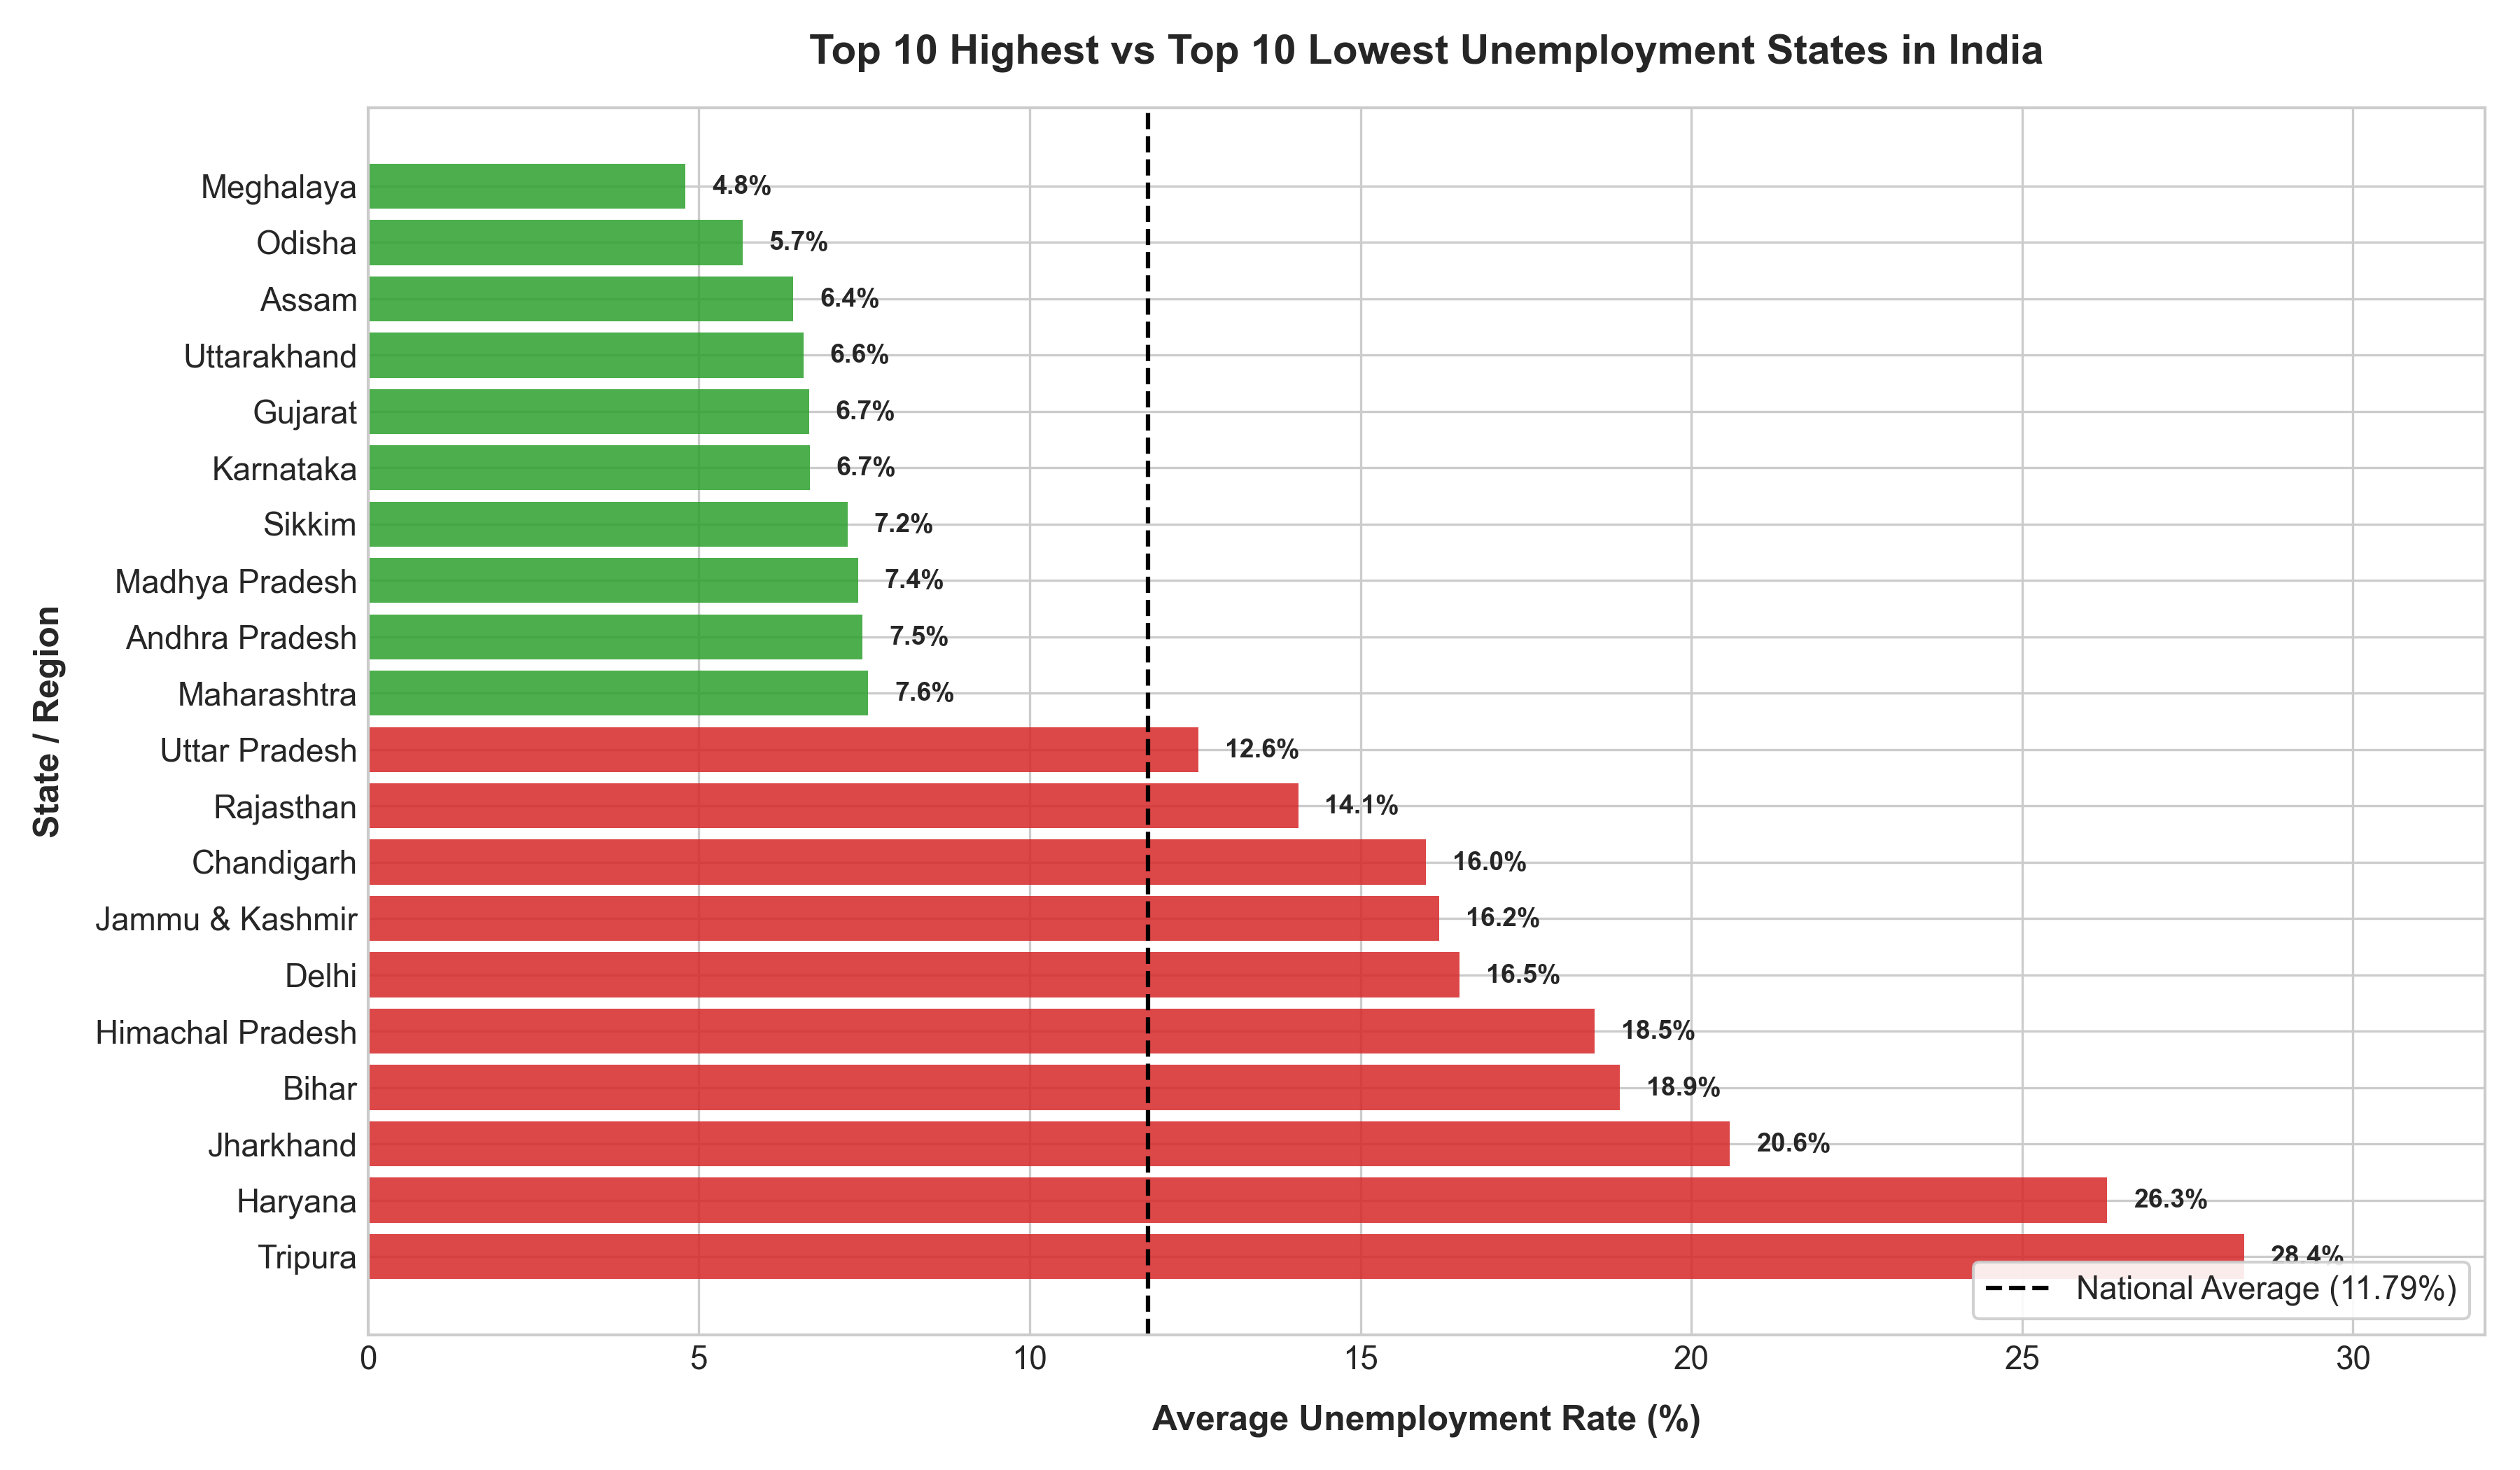

In [ ]:
# Visualization 3: Top 10 Highest vs Top 10 Lowest Unemployment States
plt.figure(figsize=(12, 7))
top_10 = state_summary['Mean_Unemployment'].sort_values(ascending=False).head(10)
bottom_10 = state_summary['Mean_Unemployment'].sort_values(ascending=True).head(10)

combined_top_bottom = pd.concat([top_10, bottom_10.iloc[::-1]])
bar_colors = ['#d62728' if st in top_10.index else '#2ca02c' for st in combined_top_bottom.index]

bars = plt.barh(combined_top_bottom.index, combined_top_bottom.values, color=bar_colors, alpha=0.85)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.4, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', 
             ha='left', va='center', fontsize=9, fontweight='bold')

overall_avg = df_clean['Estimated Unemployment Rate (%)'].mean()
plt.axvline(overall_avg, color='black', linestyle='--', linewidth=1.5, 
            label=f'National Overall Average ({overall_avg:.2f}%)')

plt.title('Figure 3: Top 10 Highest vs. Top 10 Lowest Unemployment States in India', pad=15)
plt.xlabel('Average Unemployment Rate (%)', labelpad=10)
plt.ylabel('State / Region', labelpad=10)
plt.xlim(0, 33)
plt.legend(loc='lower right', frameon=True, facecolor='white')
plt.tight_layout()
plt.show()

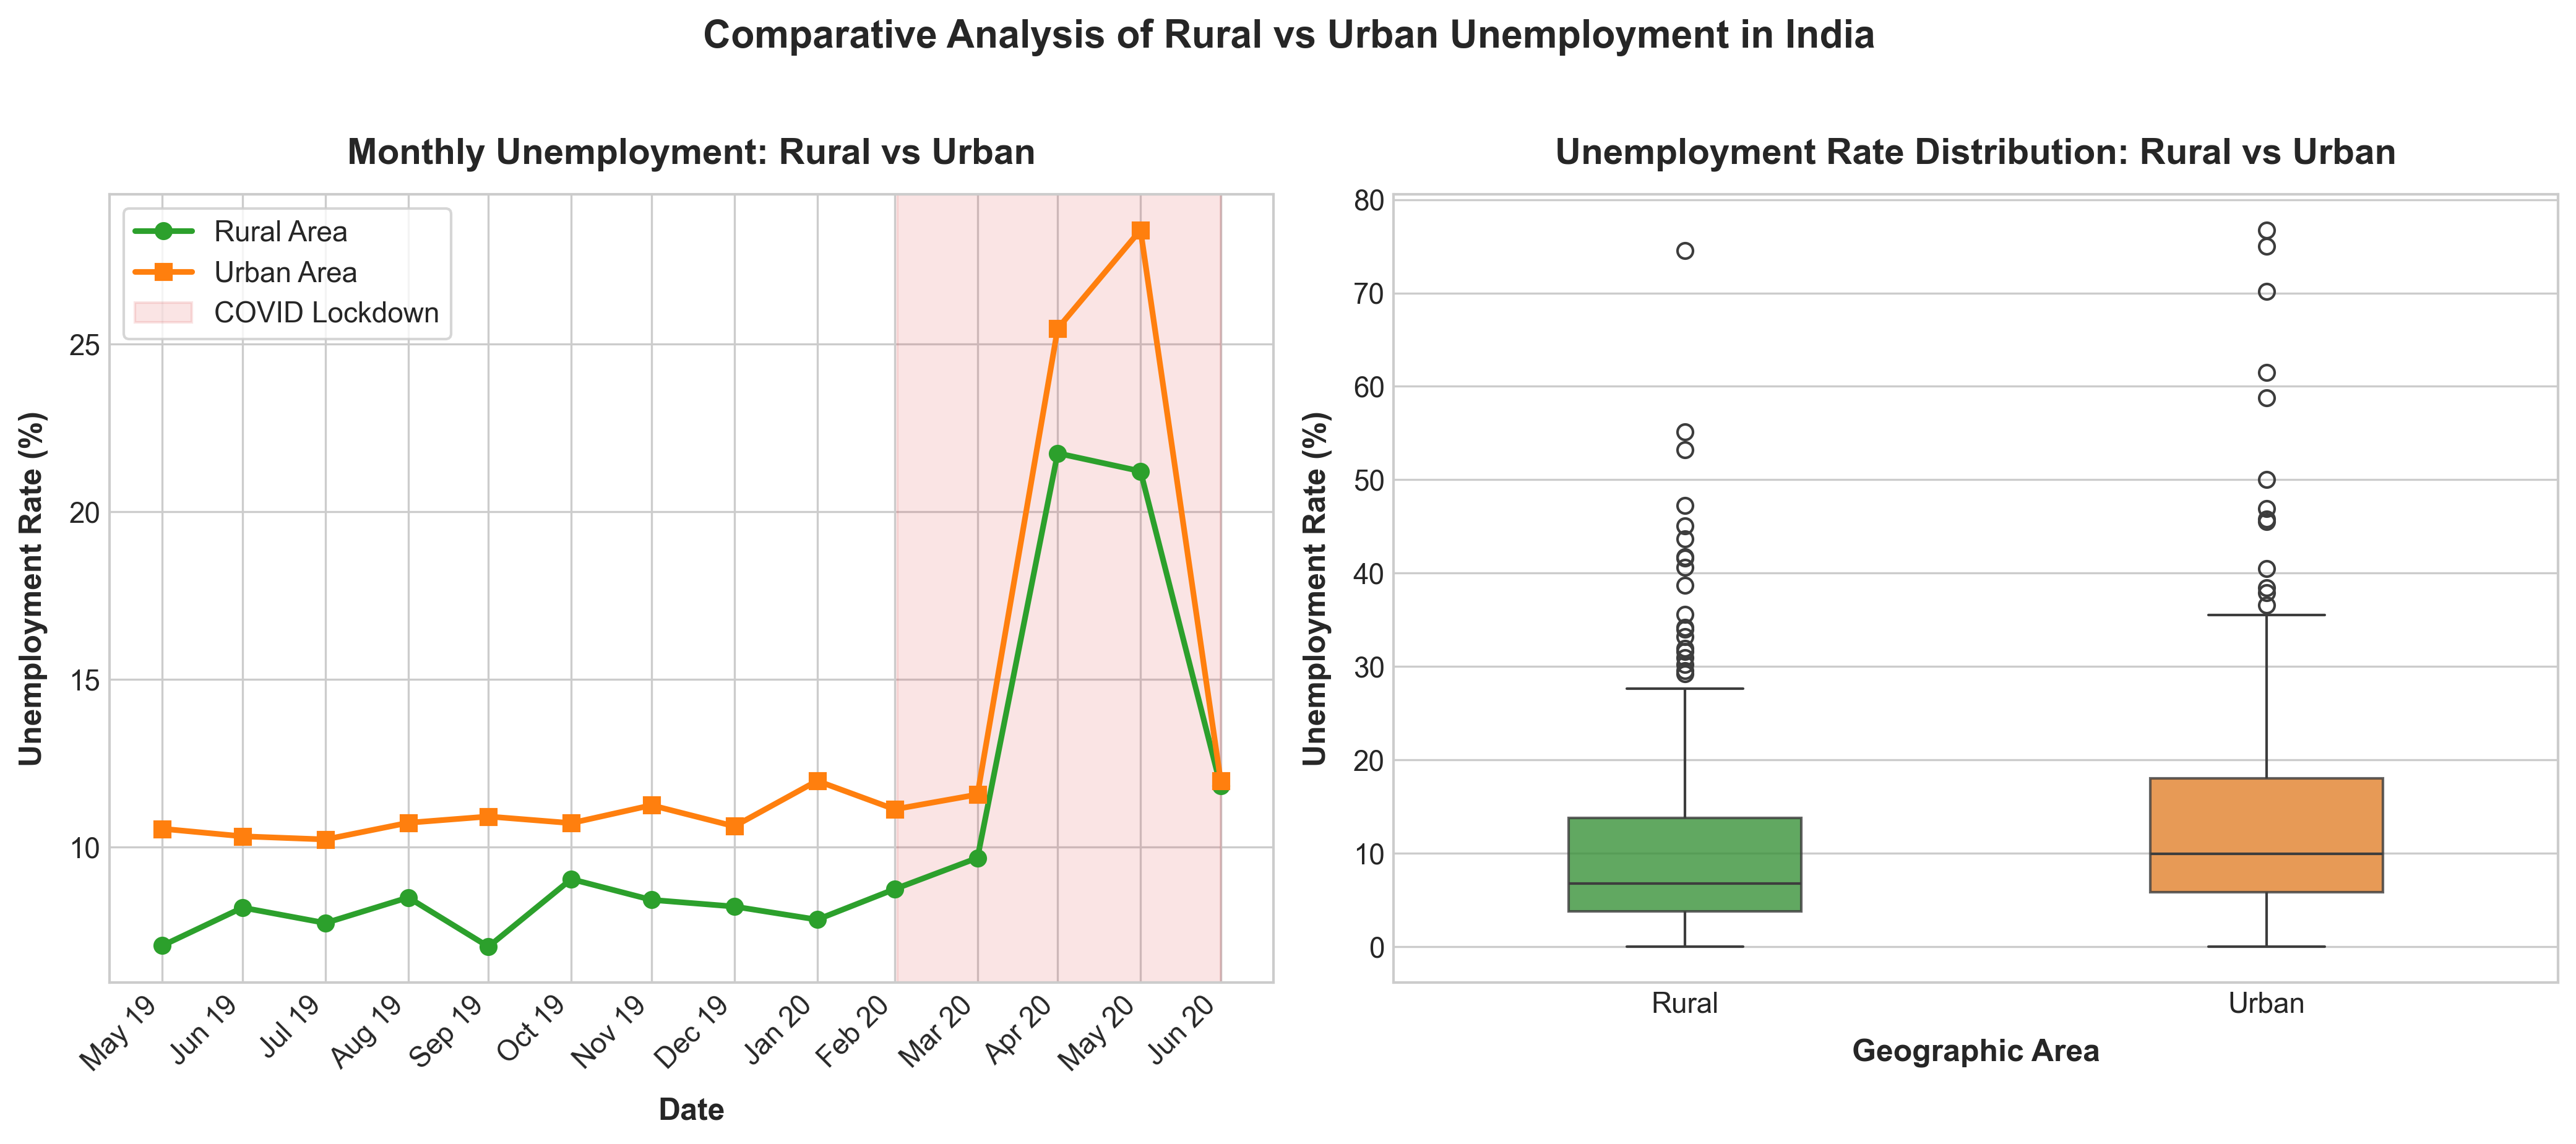

In [ ]:
# Visualization 4: Rural vs Urban Disparities
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Rural vs Urban Monthly Trends
monthly_area_plot = df_clean.groupby(['Date', 'Area'])['Estimated Unemployment Rate (%)'].mean().unstack()
ax1.plot(monthly_area_plot.index, monthly_area_plot['Rural'], marker='o', color='#2ca02c', linewidth=2.2, label='Rural Area')
ax1.plot(monthly_area_plot.index, monthly_area_plot['Urban'], marker='s', color='#ff7f0e', linewidth=2.2, label='Urban Area')
ax1.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-06-30'), color='#d62728', alpha=0.12, label='COVID Lockdown')
ax1.set_title('Monthly Unemployment Trend: Rural vs Urban', pad=12)
ax1.set_xlabel('Date', labelpad=8)
ax1.set_ylabel('Unemployment Rate (%)', labelpad=8)
ax1.set_xticks(monthly_area_plot.index)
ax1.set_xticklabels(monthly_area_plot.index.strftime('%b %y'), rotation=45, ha='right')
ax1.legend(frameon=True, facecolor='white')

# Subplot 2: Distribution Boxplot
sns.boxplot(x='Area', y='Estimated Unemployment Rate (%)', data=df_clean, 
            palette=['#2ca02c', '#ff7f0e'], ax=ax2, width=0.4, boxprops=dict(alpha=0.8))
ax2.set_title('Unemployment Rate Distribution: Rural vs Urban', pad=12)
ax2.set_xlabel('Geographic Area', labelpad=8)
ax2.set_ylabel('Unemployment Rate (%)', labelpad=8)

plt.suptitle('Figure 4: Comparative Analysis of Rural vs Urban Unemployment in India', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

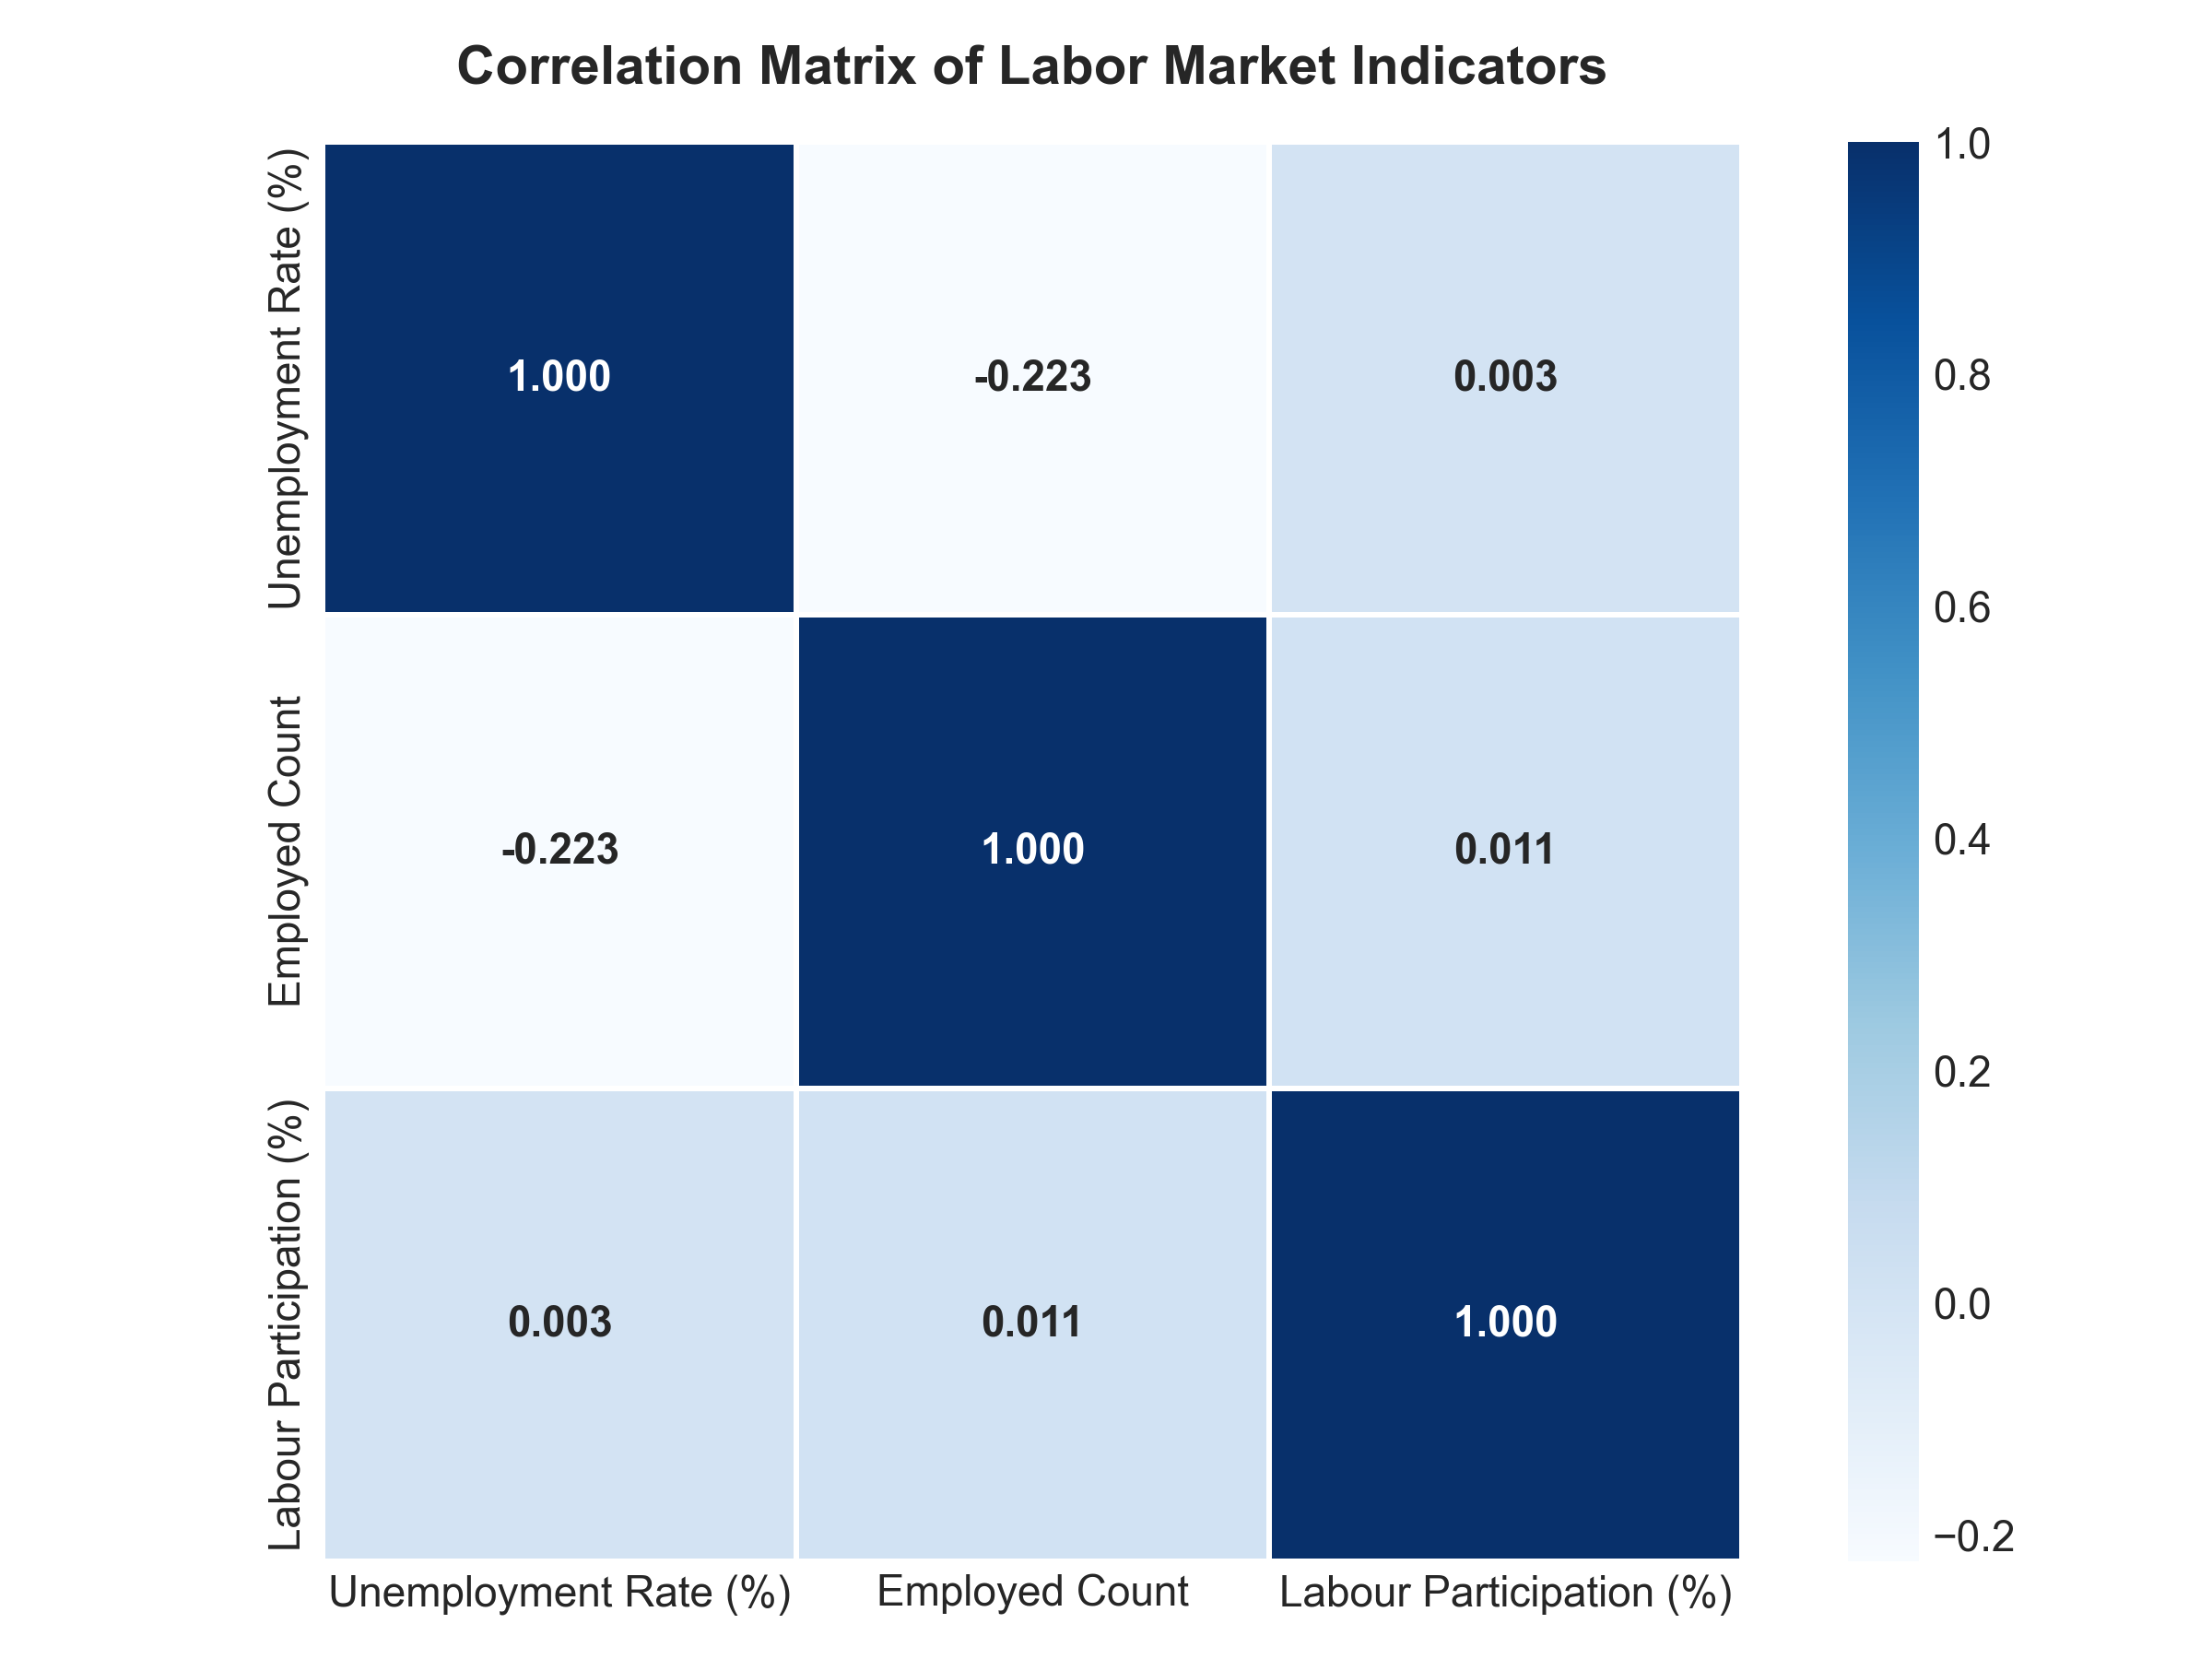

In [ ]:
# Visualization 5: Correlation Matrix Heatmap
plt.figure(figsize=(8, 6))
numeric_vars = ['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']
corr_data = df_clean[numeric_vars].corr().rename(columns={
    'Estimated Unemployment Rate (%)': 'Unemployment Rate (%)',
    'Estimated Employed': 'Employed Count',
    'Estimated Labour Participation Rate (%)': 'Labour Participation (%)'
}, index={
    'Estimated Unemployment Rate (%)': 'Unemployment Rate (%)',
    'Estimated Employed': 'Employed Count',
    'Estimated Labour Participation Rate (%)': 'Labour Participation (%)'
})

sns.heatmap(corr_data, annot=True, cmap='Blues', fmt='.3f', cbar=True, 
            square=True, linewidths=1, linecolor='white', annot_kws={'size': 11, 'weight': 'bold'})
plt.title('Figure 5: Correlation Heatmap of Labor Market Indicators', pad=15)
plt.tight_layout()
plt.show()

## 💡 12. Key Insights

Based on empirical data analysis of the Indian labor market from May 2019 to June 2020:

1. **Massive COVID-19 Shock:** National unemployment increased from a pre-lockdown average of **9.51%** (May 2019 – Feb 2020) to **17.77%** during the initial pandemic months (Mar – Jun 2020), representing an **86.91% relative increase**.
2. **Lockdown Peak in May 2020:** The unemployment rate peaked at **24.88% in May 2020** (with April 2020 close behind at **23.64%**), coinciding with strict nationwide factory, transport, and commercial shutdowns.
3. **Severe Localized Spikes:** Small union territories and states with service/tourism-dependent economies suffered the most extreme spikes. Puducherry registered the highest single unemployment rate in the dataset (**76.74%** in April 2020), followed by Jharkhand (**70.17%** in May 2020) and Bihar (**58.77%** in May 2020).
4. **Urban Areas Were Harder Hit:** Urban centers suffered higher mean unemployment (**13.17%**) compared to rural sectors (**10.32%**), driven by strict physical mobility curbs on non-agricultural businesses and daily wage service workers.
5. **Labour Force Participation Dropped:** Labour Participation dropped from **43.89%** pre-COVID to **39.33%** during lockdown, demonstrating that millions of workers temporarily exited active labor seeking due to lack of open opportunities.
6. **Persistent State Disparities:** States like **Tripura (28.35% avg)** and **Haryana (26.28% avg)** exhibited consistently high structural unemployment throughout both years, whereas **Meghalaya (4.80% avg)**, **Odisha (5.66% avg)**, and **Assam (6.43% avg)** demonstrated lower average rates.
7. **Rapid Initial Rebound (June 2020):** As phased unlocking began in June 2020, national unemployment sharply dropped from 24.88% back to **11.90%**, indicating that the spike was primarily an acute operational shock rather than permanent structural collapse.

## 🏛️ 13. Policy & Economic Implications

The observed patterns provide actionable guidance for future economic and employment policy:

1. **Targeted Urban Employment Guarantees:** While rural India benefits from rural safety nets (such as MGNREGA), the data suggests that urban daily wage earners and informal service workers are especially vulnerable during economic shocks. Introducing an *Urban Employment Guarantee Scheme* could buffer future city-level crises.
2. **Emergency Direct Benefit Transfers (DBT):** The sharp dip in employment counts during April–May 2020 highlights the necessity of automated, rapid cash and food grain transfers to maintain consumption floors among vulnerable households.
3. **Strengthening Regional Resilience:** States like Bihar, Jharkhand, and Haryana experience severe volatility during macroeconomic shocks. Targeted industrial diversification and regional skill training programs could reduce vulnerability.
4. **Digitization & Remote Workforce Infrastructure:** Sectors that could transition to remote or decentralized workflows suffered significantly fewer job losses. Expanding digital infrastructure across tier-2/3 cities provides greater economic resilience.

## 🏁 14. Conclusion

This project successfully fulfilled all requirements of **CodeAlpha Task 2: Unemployment Analysis with Python**:
- Cleaned and prepared 740 authentic labor market records.
- Conducted exploratory data analysis across states and urban/rural divides.
- Quantified the acute impact of the COVID-19 pandemic and national lockdown.
- Visualized all major trends through 5 professional charts.
- Formulated evidence-based economic policy recommendations.

---
**Project completed for CodeAlpha Data Science Internship.**